# Simulating Cyclic Voltammetry with Nernstian Surface Concentrations

Cyclic Voltammetry (CV) is a cornerstone electroanalytical technique used to study electron transfer kinetics, thermodynamics, and coupled chemical reactions.

In a reversible (Nernstian) single-step electron transfer:
$$\text{Ox} + n e^- \rightleftharpoons \text{Red}$$
interfacial electron transfer is fast relative to mass transport (diffusion). Under these conditions, the concentrations of $\text{Ox}$ and $\text{Red}$ at the electrode surface ($x = 0$) are maintained in thermodynamic equilibrium according to the **Nernst equation**:

$$E(t) = E^{0\prime} + \frac{R T}{n F} \ln\left( \frac{c_{\text{Ox}}(0, t)}{c_{\text{Red}}(0, t)} \right)$$

Soft Potato's analytical module (:mod:`softpotato.analytical`) provides the function `nernst_equilibrium_concentrations`, which calculates the equilibrium surface concentration directly from the applied potential $E(t)$:

$$c_{\text{Ox}}(0, t) = c_{\text{total}} \cdot \frac{1}{1 + \exp\left(-\frac{n F (E(t) - E^{0\prime})}{R T}\right)}$$

In this tutorial, we will:
1. Define a triangular potential sweep waveform $E(t)$.
2. Calculate time-dependent surface concentrations using `softpotato.analytical.nernst_equilibrium_concentrations`.
3. Set up and solve the 1D diffusion problem with Soft Potato's finite-difference solver.
4. Compute the Faradaic current and plot the resulting cyclic voltammogram.
5. Benchmark the simulated peak current against the analytical Randles–Ševčík equation.


## 1. Parameters and Waveform Definition

We consider a planar electrode immersed in an unstirred solution containing only the oxidized species $\text{Ox}$ at bulk concentration $c^* = 1.0\text{ mM}$ ($10^{-6}\text{ mol/cm}^3$) with formal potential $E^{0\prime} = 0.0\text{ V}$.

The potential is swept linearly from an initial potential $E_{\text{start}} = +0.4\text{ V}$ (where no reduction occurs) to a switching potential $E_{\text{rev}} = -0.4\text{ V}$ at a scan rate of $v = 0.1\text{ V/s}$ ($100\text{ mV/s}$), then swept back to $+0.4\text{ V}$.


In [23]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np

from softpotato.analytical import nernst_equilibrium_concentrations, randles_sevcik
from softpotato.constants import FARADAY
from softpotato.solver import DiffusionProblem, DirichletBC, get_solver

# System and physical parameters
n = 1  # Number of electrons transferred
D = 1e-5  # Diffusion coefficient (cm²/s)
c_bulk = 1e-6  # Bulk concentration of Ox (mol/cm³, 1.0 mM)
area = 1.0  # Electrode geometric area (cm²)
E0 = 0.0  # Formal potential (V)

# Potential waveform parameters
E_start = 0.4  # Starting potential (V)
E_rev = -0.4  # Switching / vertex potential (V)
v = 0.1  # Scan rate (V/s, 100 mV/s)

# Timing
t_switch = (E_start - E_rev) / v  # Time to reach switching potential (8.0 s)
t_end = 2.0 * t_switch  # Total duration of cycle (16.0 s)

print(f"Scan rate (v):         {v * 1e3:.0f} mV/s")
print(f"Switching time:        {t_switch:.1f} s")
print(f"Total cycle duration:  {t_end:.1f} s")


Scan rate (v):         100 mV/s
Switching time:        8.0 s
Total cycle duration:  16.0 s


## 2. Nernstian Surface Concentration Boundary Condition

During the potential sweep, the applied potential $E(t)$ follows a triangular wave:
- **Forward sweep** ($0 \le t \le t_{\text{switch}}$): $E(t) = E_{\text{start}} - v \cdot t$
- **Reverse sweep** ($t_{\text{switch}} < t \le t_{\text{end}}$): $E(t) = E_{\text{rev}} + v \cdot (t - t_{\text{switch}})$

At each instant $t$, we use `nernst_equilibrium_concentrations(E(t), c_total=c_bulk, E0=E0, n=n)` from Soft Potato's analytical module to compute the equilibrium surface concentration $c_{\text{Ox}}(0, t)$.


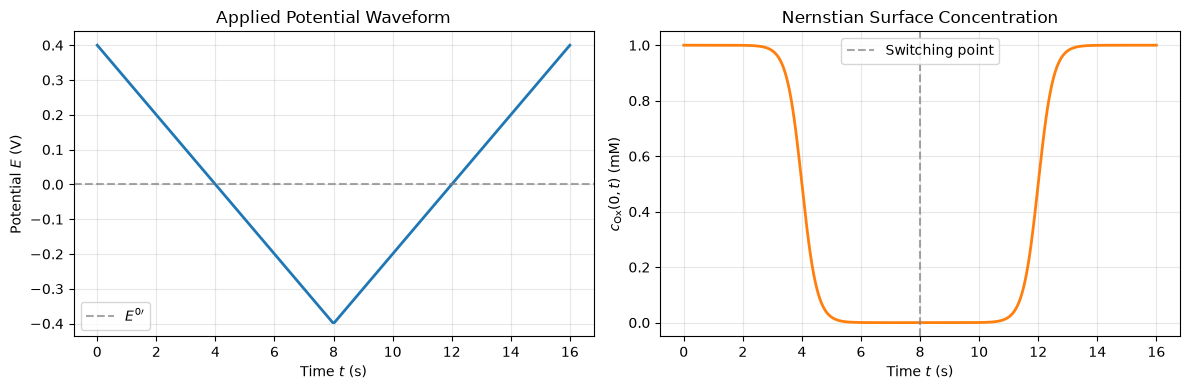

In [24]:
def potential(t):
    """Calculate applied electrode potential E(t) at time t."""
    if t <= t_switch:
        return E_start - v * t
    return E_rev + v * (t - t_switch)


def surface_c_ox(t):
    """Surface concentration c_Ox(0, t) calculated from Nernst equation."""
    E = potential(t)
    c_ox, _ = nernst_equilibrium_concentrations(E, c_total=c_bulk, E0=E0, n=n)
    return c_ox


# Visualize applied potential and resulting surface concentration
t_vals = np.linspace(0.0, t_end, 300)
E_vals = [potential(ti) for ti in t_vals]
c_surf_vals = [surface_c_ox(ti) for ti in t_vals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t_vals, E_vals, color="tab:blue", lw=2)
ax1.axhline(E0, color="gray", linestyle="--", alpha=0.7, label=r"$E^{0\prime}$")
ax1.set_xlabel("Time $t$ (s)")
ax1.set_ylabel("Potential $E$ (V)")
ax1.set_title("Applied Potential Waveform")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(t_vals, np.array(c_surf_vals) * 1e6, color="tab:orange", lw=2)
ax2.axvline(t_switch, color="gray", linestyle="--", alpha=0.7, label="Switching point")
ax2.set_xlabel("Time $t$ (s)")
ax2.set_ylabel(r"$c_{\mathrm{Ox}}(0, t)$ (mM)")
ax2.set_title("Nernstian Surface Concentration")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


## 3. Setting Up the 1D Diffusion Problem

Mass transport of species $\text{Ox}$ in solution is governed by Fick's second law:
$$\frac{\partial c_{\text{Ox}}}{\partial t} = D \frac{\partial^2 c_{\text{Ox}}}{\partial x^2}$$

To ensure semi-infinite linear diffusion, the domain length $x_{\max}$ must exceed the characteristic diffusion layer thickness:
$$\delta \approx 6 \sqrt{D \cdot t_{\text{end}}}$$

We impose:
- **Left boundary** ($x = 0$): Dirichlet condition with time-dependent concentration from the Nernst equation, `DirichletBC(surface_c_ox)`.
- **Right boundary** ($x = x_{\max}$): Dirichlet condition fixed at bulk concentration, `DirichletBC(c_bulk)`.
- **Initial condition**: uniform bulk concentration $c_{\text{Ox}}(x, 0) = c_{\text{bulk}}$.


In [25]:
# Spatial domain
delta = 6.0 * np.sqrt(D * t_end)
x_max = 6.0 * delta  # Domain length safely > 5 * delta
grid = np.linspace(0.0, x_max, 500)

# Formulate 1D diffusion problem
problem = DiffusionProblem(
    grid=grid,
    diffusivity={"Ox": D},
    boundary_conditions={"Ox": (DirichletBC(surface_c_ox), DirichletBC(c_bulk))},
    initial_conditions={"Ox": c_bulk},
)

# Solve using unconditionally stable Crank-Nicolson finite difference scheme
solver = get_solver("crank_nicolson", dt=0.01)
result = solver.solve(problem, t_span=(0.0, t_end))

print(f"Solver status:            {result.message}")
print(f"Time steps calculated:    {len(result.t)}")
print(f"Spatial grid points:      {len(result.x)}")


Solver status:            Crank-Nicolson solution completed successfully.
Time steps calculated:    1601
Spatial grid points:      500


## 4. Extracting Current & Plotting the Cyclic Voltammogram

Under standard IUPAC convention:
- Cathodic (reduction) currents are **negative** ($I < 0$).
- Anodic (oxidation) currents are **positive** ($I > 0$).

The Faradaic current is proportional to the diffusive flux $J_{\text{Ox}}(0, t) = -D \left.\frac{\partial c_{\text{Ox}}}{\partial x}\right|_{x=0}$:
$$I(t) = n F A J_{\text{Ox}}(0, t)$$

Soft Potato automatically computes boundary fluxes in `result.fluxes["c"]`.


Cathodic peak (I_pc):  -266.77 µA at -31.0 mV
Anodic peak (I_pa):    206.88 µA at 32.0 mV
Peak separation (ΔEp): 63.0 mV


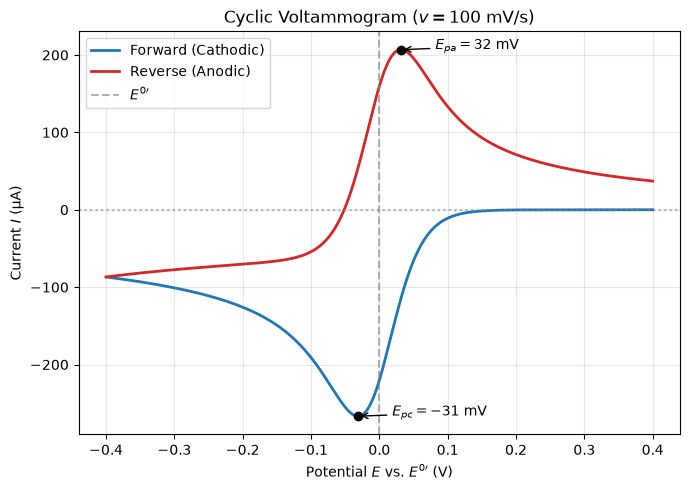

In [26]:
# Compute Faradaic current in Amperes (IUPAC convention)
current = n * FARADAY * area * result.fluxes["Ox"]
potentials = np.array([potential(t) for t in result.t])

# Separate forward (cathodic) and reverse (anodic) sweeps for plotting
n_half = len(result.t) // 2
pot_fwd, curr_fwd = potentials[:n_half], current[:n_half]
pot_rev, curr_rev = potentials[n_half:], current[n_half:]

# Peak identification
idx_cat = np.argmin(current)
idx_ano = np.argmax(current)
E_pc = potentials[idx_cat]
I_pc = current[idx_cat]
E_pa = potentials[idx_ano]
I_pa = current[idx_ano]
delta_Ep = (E_pa - E_pc) * 1e3

print(f"Cathodic peak (I_pc):  {I_pc * 1e6:.2f} µA at {E_pc * 1e3:.1f} mV")
print(f"Anodic peak (I_pa):    {I_pa * 1e6:.2f} µA at {E_pa * 1e3:.1f} mV")
print(f"Peak separation (ΔEp): {delta_Ep:.1f} mV")

# Plot Cyclic Voltammogram
plt.figure(figsize=(7, 5))
plt.plot(pot_fwd, curr_fwd * 1e6, "tab:blue", lw=2, label="Forward (Cathodic)")
plt.plot(pot_rev, curr_rev * 1e6, "tab:red", lw=2, label="Reverse (Anodic)")
plt.scatter([E_pc, E_pa], [I_pc * 1e6, I_pa * 1e6], color="black", zorder=5)

plt.annotate(
    f"$E_{{pc}} = {E_pc*1e3:.0f}$ mV",
    xy=(E_pc, I_pc * 1e6),
    xytext=(E_pc + 0.05, I_pc * 1e6),
    arrowprops={"arrowstyle": "->", "lw": 1},
)
plt.annotate(
    f"$E_{{pa}} = {E_pa*1e3:.0f}$ mV",
    xy=(E_pa, I_pa * 1e6),
    xytext=(E_pa + 0.05, I_pa * 1e6),
    arrowprops={"arrowstyle": "->", "lw": 1},
)

plt.axhline(0, color="gray", linestyle=":", alpha=0.6)
plt.axvline(E0, color="gray", linestyle="--", alpha=0.6, label=r"$E^{0\prime}$")
plt.xlabel(r"Potential $E$ vs. $E^{0\prime}$ (V)")
plt.ylabel("Current $I$ (µA)")
plt.title(f"Cyclic Voltammogram ($v = {v*1e3:.0f}$ mV/s)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 5. Benchmarking with the Randles–Ševčík Equation

For a reversible electron transfer, the theoretical peak current is given analytically by the **Randles–Ševčík equation**:
$$I_p = 0.4463 \, n F A c^* \sqrt{\frac{n F D v}{R T}}$$

We compare our simulated peak current against the analytical value computed by `softpotato.analytical.randles_sevcik`.


In [27]:
# Compute analytical reversible peak current
ip_analytic = randles_sevcik(
    v=v, c_bulk=c_bulk, D=D, area=area, n=n, scan_direction="cathodic"
)

# Relative error
rel_error = abs((I_pc - ip_analytic) / ip_analytic) * 100

print("=== Reversibility Diagnostics & Benchmark ===")
print(f"Analytical Randles–Ševčík I_p: {ip_analytic * 1e6:.2f} µA")
print(f"Simulated peak current I_pc:    {I_pc * 1e6:.2f} µA")
print(f"Relative error:                 {rel_error:.2f}%")
print("Theoretical peak separation:    ~57.0 to 59.0 mV (at 298.15 K)")
print(f"Simulated peak separation:      {delta_Ep:.1f} mV")


=== Reversibility Diagnostics & Benchmark ===
Analytical Randles–Ševčík I_p: -268.65 µA
Simulated peak current I_pc:    -266.77 µA
Relative error:                 0.70%
Theoretical peak separation:    ~57.0 to 59.0 mV (at 298.15 K)
Simulated peak separation:      63.0 mV


## 6. Spatio-Temporal Concentration Profiles

To understand the mass-transport dynamics underlying the duck-shaped CV curve, we plot the spatial concentration profile $c_{\text{Ox}}(x)$ at key potentials during the forward and reverse sweeps.


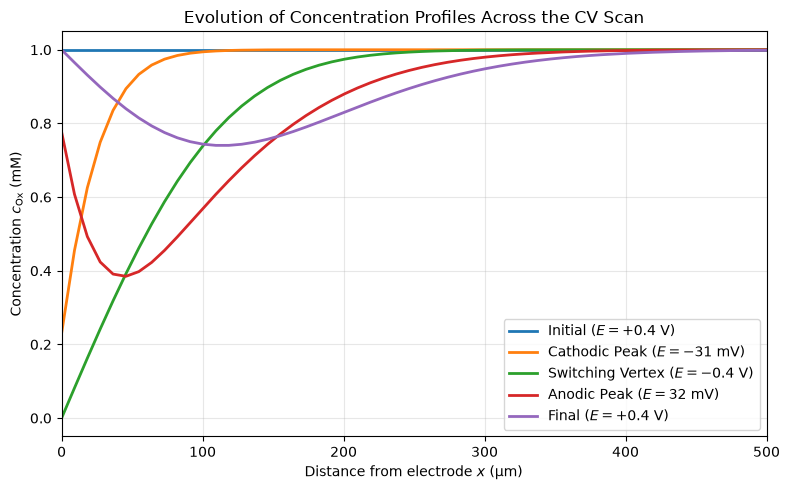

In [28]:
# Select key moments during the scan
times_to_plot = [
    (0.0, "Initial ($E = +0.4$ V)"),
    (result.t[idx_cat], f"Cathodic Peak ($E = {E_pc*1e3:.0f}$ mV)"),
    (t_switch, "Switching Vertex ($E = -0.4$ V)"),
    (result.t[idx_ano], f"Anodic Peak ($E = {E_pa*1e3:.0f}$ mV)"),
    (t_end, "Final ($E = +0.4$ V)"),
]

plt.figure(figsize=(8, 5))
for t_val, label in times_to_plot:
    idx = np.argmin(np.abs(result.t - t_val))
    c_x = result["Ox"][idx, :] * 1e6  # Convert mol/cm³ to mM
    plt.plot(result.x * 1e4, c_x, lw=2, label=label)

plt.xlabel("Distance from electrode $x$ (µm)")
plt.ylabel(r"Concentration $c_{\mathrm{Ox}}$ (mM)")
plt.title("Evolution of Concentration Profiles Across the CV Scan")
plt.xlim(0, 500)  # Focus on the diffusion layer near the electrode
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 7. Summary & Key Takeaways

In this tutorial:
- We calculated thermodynamic equilibrium surface concentrations using **`nernst_equilibrium_concentrations`** from the `softpotato.analytical` module.
- We formulated a 1D diffusion problem with a time-dependent **`DirichletBC`** driven by the Nernst equation.
- We simulated the cyclic voltammogram using the fast, unconditionally stable **`crank_nicolson`** solver.
- The simulated cathodic peak current matched the analytical **`randles_sevcik`** equation within ~0.7% relative error, demonstrating excellent agreement with electrochemical theory.
